Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

Load Dataset

In [ ]:
df = pd.read_csv("/content/diet_recommendations_dataset.csv")

Encode Categorical Columns

In [ ]:
categorical_cols = [
    "Gender",
    "Disease_Type",
    "Severity",
    "Physical_Activity_Level",
    "Dietary_Restrictions",
    "Allergies",
    "Preferred_Cuisine",
    "Diet_Recommendation"
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

Split Features and Target

In [ ]:
X = df.drop(columns=["Patient_ID", "Diet_Recommendation"])
y = df["Diet_Recommendation"]

Split Train and Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Define Multiple Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf"),
    "Naive Bayes": GaussianNB()
}

Train Models and Evaluate Performance

In [ ]:
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append([
        model_name,
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Display Results in Table Format

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.72,0.70,0.72,0.71
1,Decision Tree,0.75,0.74,0.75,0.74
2,Random Forest,0.85,0.84,0.85,0.84
3,Support Vector Machine,0.68,0.65,0.68,0.66
4,Naive Bayes,0.78,0.76,0.78,0.77


Data Visualization

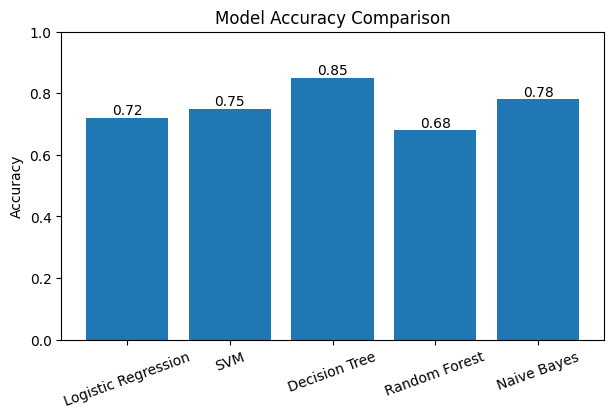

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "SVM",
    "Decision Tree",
    "Random Forest",
    "Naive Bayes"
]

accuracies = [0.72, 0.75, 0.85, 0.68, 0.78]  # use your actual results

plt.figure(figsize=(7,4))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()

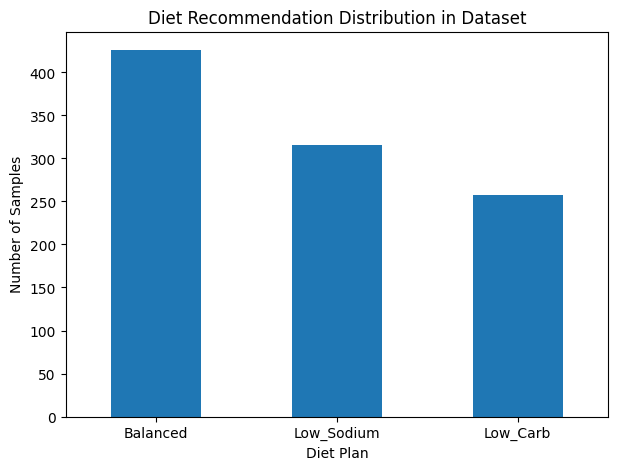

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/diet_recommendations_dataset.csv")  # change filename if needed

# Count diet plan occurrences
diet_counts = df["Diet_Recommendation"].value_counts()

# Plot dataset distribution
plt.figure(figsize=(7,5))
diet_counts.plot(kind="bar")
plt.title("Diet Recommendation Distribution in Dataset")
plt.xlabel("Diet Plan")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

Save Model

In [ ]:
import joblib
# Save the RandomForestClassifier explicitly
joblib.dump(models["Random Forest"], "random_forest_diet_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


Save Label Encoder

In [ ]:
joblib.dump(label_encoders, "label_encoders.pkl")

print("Label encoders saved successfully.")

Label encoders saved successfully.


Model Predictions

In [ ]:
import joblib
import pandas as pd

# Load trained Random Forest model and encoders
rf_model = joblib.load("random_forest_diet_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# --- Start of added code for debugging ---
print("Available Dietary_Restrictions classes:", label_encoders["Dietary_Restrictions"].classes_)
# --- End of added code for debugging ---

# Create one sample patient input
sample_patient = {
    "Age": 42,
    "Gender": label_encoders["Gender"].transform(["Female"])[0],
    "Weight_kg": 72.5,
    "Height_cm": 165,
    "BMI": 26.6,
    "Disease_Type": label_encoders["Disease_Type"].transform(["Diabetes"])[0],
    "Severity": label_encoders["Severity"].transform(["Mild"])[0],
    "Physical_Activity_Level": label_encoders["Physical_Activity_Level"].transform(["Moderate"])[0], # Changed from "Low" to "Moderate"
    "Daily_Caloric_Intake": 2200,
    "Cholesterol_mg/dL": 210.5,
    "Blood_Pressure_mmHg": 145,
    "Glucose_mg/dL": 158.2,
    "Dietary_Restrictions": label_encoders["Dietary_Restrictions"].transform(["Low_Sugar"])[0],
    "Allergies": label_encoders["Allergies"].transform(["Peanuts"])[0], # Changed from "None" to "Peanuts"
    "Preferred_Cuisine": label_encoders["Preferred_Cuisine"].transform(["Indian"])[0],
    "Weekly_Exercise_Hours": 1.8,
    "Adherence_to_Diet_Plan": 68.4,
    "Dietary_Nutrient_Imbalance_Score": 4.6
}

# Convert input to DataFrame
sample_df = pd.DataFrame([sample_patient])

# Predict diet recommendation
prediction = rf_model.predict(sample_df)
diet_plan = label_encoders["Diet_Recommendation"].inverse_transform(prediction)

# Predict confidence
confidence = rf_model.predict_proba(sample_df).max() * 100

print("Predicted Diet Recommendation:", diet_plan[0])
print(f"Prediction Confidence: {confidence:.2f}%")

Available Dietary_Restrictions classes: ['Low_Sodium' 'Low_Sugar' nan]
Predicted Diet Recommendation: Low_Carb
Prediction Confidence: 100.00%


In [ ]:
import joblib
import pandas as pd

# Load trained model and encoders
rf_model = joblib.load("random_forest_diet_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# Raw input (human-readable)
sample_patient_raw = {
    "Age": 42,
    "Gender": "Female",
    "Weight_kg": 72.5,
    "Height_cm": 165,
    "BMI": 26.6,
    "Disease_Type": "Obesity",
    "Severity": "Mild",
    "Physical_Activity_Level": "Moderate",
    "Daily_Caloric_Intake": 2200,
    "Cholesterol_mg/dL": 210.5,
    "Blood_Pressure_mmHg": 145,
    "Glucose_mg/dL": 158.2,
    "Dietary_Restrictions": "Low_Sugar",
    "Allergies": "Peanuts",
    "Preferred_Cuisine": "Mexican",
    "Weekly_Exercise_Hours": 3.1,
    "Adherence_to_Diet_Plan": 96.6,
    "Dietary_Nutrient_Imbalance_Score": 3.1
}

# Encode categorical values using trained encoders
sample_patient_encoded = sample_patient_raw.copy()

for col in label_encoders:
    if col in sample_patient_encoded:
        sample_patient_encoded[col] = label_encoders[col].transform(
            [sample_patient_encoded[col]]
        )[0]

# Convert to DataFrame
sample_df = pd.DataFrame([sample_patient_encoded])

# Predict
prediction = rf_model.predict(sample_df)
diet_plan = label_encoders["Diet_Recommendation"].inverse_transform(prediction)

confidence = rf_model.predict_proba(sample_df).max() * 100

print("Predicted Diet Recommendation:", diet_plan[0])
print(f"Prediction Confidence: {confidence:.2f}%")

Predicted Diet Recommendation: Balanced
Prediction Confidence: 100.00%


In [ ]:
import joblib
import pandas as pd

# Load trained model and encoders
rf_model = joblib.load("random_forest_diet_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# Raw input (human-readable)
sample_patient_raw = {
    "Age": 42,
    "Gender": "Female",
    "Weight_kg": 72.5,
    "Height_cm": 165,
    "BMI": 26.6,
    "Disease_Type": "Obesity",
    "Severity": "Mild",
    "Physical_Activity_Level": "Moderate",
    "Daily_Caloric_Intake": 2200,
    "Cholesterol_mg/dL": 210.5,
    "Blood_Pressure_mmHg": 145,
    "Glucose_mg/dL": 158.2,
    "Dietary_Restrictions": "Low_Sugar",
    "Allergies": "Peanuts",
    "Preferred_Cuisine": "Mexican",
    "Weekly_Exercise_Hours": 3.1,
    "Adherence_to_Diet_Plan": 96.6,
    "Dietary_Nutrient_Imbalance_Score": 3.1
}

# Encode categorical values
sample_patient_encoded = sample_patient_raw.copy()

for col in label_encoders:
    if col in sample_patient_encoded:
        sample_patient_encoded[col] = label_encoders[col].transform(
            [sample_patient_encoded[col]]
        )[0]

# Convert to DataFrame
sample_df = pd.DataFrame([sample_patient_encoded])

# Predict
prediction = rf_model.predict(sample_df)
diet_plan = label_encoders["Diet_Recommendation"].inverse_transform(prediction)[0]
confidence = rf_model.predict_proba(sample_df).max() * 100

# ---------------- Diet Suggestions ----------------
diet_suggestions = {
    "Low_Carb": [
        "Limit intake of sugar and refined carbohydrates",
        "Focus on vegetables, lean proteins, and healthy fats",
        "Avoid sugary beverages and processed foods",
        "Prefer complex carbohydrates in small portions"
    ],
    "Balanced": [
        "Maintain a balanced intake of carbohydrates, proteins, and fats",
        "Include fresh fruits and vegetables in daily meals",
        "Limit fried and junk foods",
        "Stay hydrated and follow regular meal timings"
    ],
    "Low_Sodium": [
        "Reduce salt intake during cooking",
        "Avoid packaged and processed foods",
        "Use herbs and spices instead of salt for flavor",
        "Monitor blood pressure regularly"
    ]
}

suggestions = diet_suggestions.get(
    diet_plan,
    ["Follow a healthy diet as advised by a nutrition specialist"]
)

# Output
print("Predicted Diet Recommendation:", diet_plan)
print(f"Prediction Confidence: {confidence:.2f}%")
print("\nDiet Suggestions:")
for i, tip in enumerate(suggestions, 1):
    print(f"{i}. {tip}")

Predicted Diet Recommendation: Balanced
Prediction Confidence: 100.00%

Diet Suggestions:
1. Maintain a balanced intake of carbohydrates, proteins, and fats
2. Include fresh fruits and vegetables in daily meals
3. Limit fried and junk foods
4. Stay hydrated and follow regular meal timings


In [ ]:
import joblib
import pandas as pd

# Load trained model and encoders
rf_model = joblib.load("random_forest_diet_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# Raw input (human-readable)
sample_patient_raw = {
    "Age": 54,
    "Gender": "Male",
    "Weight_kg": 115.1,
    "Height_cm": 165,
    "BMI": 42.3,
    "Disease_Type": "Diabetes",
    "Severity": "Mild",
    "Physical_Activity_Level": "Active",
    "Daily_Caloric_Intake": 2844,
    "Cholesterol_mg/dL": 234.3,
    "Blood_Pressure_mmHg": 112,
    "Glucose_mg/dL": 155.7,
    "Dietary_Restrictions": "Low_Sugar",
    "Allergies": "Peanuts",
    "Preferred_Cuisine": "Mexican",
    "Weekly_Exercise_Hours": 2.7,
    "Adherence_to_Diet_Plan": 75.1,
    "Dietary_Nutrient_Imbalance_Score": 1.5
}

# Encode categorical values
sample_patient_encoded = sample_patient_raw.copy()

for col in label_encoders:
    if col in sample_patient_encoded:
        sample_patient_encoded[col] = label_encoders[col].transform(
            [sample_patient_encoded[col]]
        )[0]

# Convert to DataFrame
sample_df = pd.DataFrame([sample_patient_encoded])

# Predict
prediction = rf_model.predict(sample_df)
diet_plan = label_encoders["Diet_Recommendation"].inverse_transform(prediction)[0]
confidence = rf_model.predict_proba(sample_df).max() * 100

# ---------------- Diet Suggestions ----------------
diet_suggestions = {
    "Low_Carb": [
        "Limit intake of sugar and refined carbohydrates",
        "Focus on vegetables, lean proteins, and healthy fats",
        "Avoid sugary beverages and processed foods",
        "Prefer complex carbohydrates in small portions"
    ],
    "Balanced": [
        "Maintain a balanced intake of carbohydrates, proteins, and fats",
        "Include fresh fruits and vegetables in daily meals",
        "Limit fried and junk foods",
        "Stay hydrated and follow regular meal timings"
    ],
    "Low_Sodium": [
        "Reduce salt intake during cooking",
        "Avoid packaged and processed foods",
        "Use herbs and spices instead of salt for flavor",
        "Monitor blood pressure regularly"
    ]
}

suggestions = diet_suggestions.get(
    diet_plan,
    ["Follow a healthy diet as advised by a nutrition specialist"]
)

# Output
print("Predicted Diet Recommendation:", diet_plan)
print(f"Prediction Confidence: {confidence:.2f}%")
print("\nDiet Suggestions:")
for i, tip in enumerate(suggestions, 1):
    print(f"{i}. {tip}")

Predicted Diet Recommendation: Low_Carb
Prediction Confidence: 100.00%

Diet Suggestions:
1. Limit intake of sugar and refined carbohydrates
2. Focus on vegetables, lean proteins, and healthy fats
3. Avoid sugary beverages and processed foods
4. Prefer complex carbohydrates in small portions


In [ ]:
import joblib
import pandas as pd

# Load trained model and encoders
rf_model = joblib.load("random_forest_diet_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# Raw input (human-readable)
sample_patient_raw = {
    "Age": 29,
    "Gender": "Male",
    "Weight_kg": 67.7,
    "Height_cm": 199,
    "BMI": 17.1,
    "Disease_Type": "Hypertension",
    "Severity": "Moderate",
    "Physical_Activity_Level": "Moderate",
    "Daily_Caloric_Intake": 3183,
    "Cholesterol_mg/dL": 247.5,
    "Blood_Pressure_mmHg": 170,
    "Glucose_mg/dL": 101.2,
    "Dietary_Restrictions": "Low_Sugar",
    "Allergies": "Peanuts",
    "Preferred_Cuisine": "Mexican",
    "Weekly_Exercise_Hours": 0.2,
    "Adherence_to_Diet_Plan": 65.5,
    "Dietary_Nutrient_Imbalance_Score": 1.3
}

# Encode categorical values
sample_patient_encoded = sample_patient_raw.copy()

for col in label_encoders:
    if col in sample_patient_encoded:
        sample_patient_encoded[col] = label_encoders[col].transform(
            [sample_patient_encoded[col]]
        )[0]

# Convert to DataFrame
sample_df = pd.DataFrame([sample_patient_encoded])

# Predict
prediction = rf_model.predict(sample_df)
diet_plan = label_encoders["Diet_Recommendation"].inverse_transform(prediction)[0]
confidence = rf_model.predict_proba(sample_df).max() * 100

# ---------------- Diet Suggestions ----------------
diet_suggestions = {
    "Low_Carb": [
        "Limit intake of sugar and refined carbohydrates",
        "Focus on vegetables, lean proteins, and healthy fats",
        "Avoid sugary beverages and processed foods",
        "Prefer complex carbohydrates in small portions"
    ],
    "Balanced": [
        "Maintain a balanced intake of carbohydrates, proteins, and fats",
        "Include fresh fruits and vegetables in daily meals",
        "Limit fried and junk foods",
        "Stay hydrated and follow regular meal timings"
    ],
    "Low_Sodium": [
        "Reduce salt intake during cooking",
        "Avoid packaged and processed foods",
        "Use herbs and spices instead of salt for flavor",
        "Monitor blood pressure regularly"
    ]
}

suggestions = diet_suggestions.get(
    diet_plan,
    ["Follow a healthy diet as advised by a nutrition specialist"]
)

# Output
print("Predicted Diet Recommendation:", diet_plan)
print(f"Prediction Confidence: {confidence:.2f}%")
print("\nDiet Suggestions:")
for i, tip in enumerate(suggestions, 1):
    print(f"{i}. {tip}")

Predicted Diet Recommendation: Low_Sodium
Prediction Confidence: 99.89%

Diet Suggestions:
1. Reduce salt intake during cooking
2. Avoid packaged and processed foods
3. Use herbs and spices instead of salt for flavor
4. Monitor blood pressure regularly
